# Health insurance: análisis exploratorio

Analisis exploratorio del dataset "insurance".

Este conjunto de datos viene integrado en la librería pycaret.
    
- **Variables numéricas**:

  - **age**: edad de los individuos
  - **bmi**: Body Mass Index (BMI).
  - **children**: número de hijos cubiertos por el seguro de salud
  - **charges**: poliza en USD

- **Variables categóricas**:

  - **sex**: genero (male, female).
  - **smoker**: fumador (yes, no).
  - **region**: Región de residencia (northeast, northwest, southeast, southwest).

Algunas conclusiones del análisis gráfico son:

- Ser fumador penaliza gravemente la poliza
- El indice de masa corporal BMI penaliza la póliza en el grupo de fumadores mucho más que en el grupo de no fumadores.
- La edad: los suscriptores de mayor edad pagan una póliza más alta
- Hay algunas diferencias entre las regiones

In [2]:
import pycaret

pycaret.__version__

'3.3.2'

In [3]:
from pycaret.datasets import get_data
data = get_data("insurance")


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


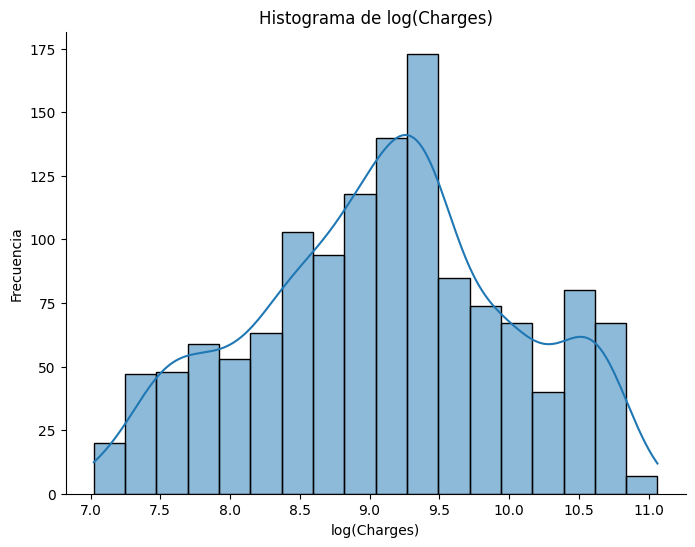

In [ ]:
# los datos están sesgados
# realizamos una transformación logarítmica
# para tratar de transformarlos en una dis

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Apply logarithmic transformation to 'charges'
data['log_charges'] = np.log1p(data['charges'])

# Create the histogram using matplotlib and seaborn
plt.figure(figsize=(8, 6))
sns.histplot(data['log_charges'], kde=True)
plt.title('Histograma de log(Charges)')
plt.xlabel('log(Charges)')
plt.ylabel('Frecuencia')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Distribution of Categorical Variables')

sns.countplot(x='sex', data=data, ax=axes[0])
axes[0].set_title('Gender Distribution')

sns.countplot(x='smoker', data=data, ax=axes[1])
axes[1].set_title('Smoker Distribution')

sns.countplot(x='region', data=ance_data, ax=axes[2])
axes[2].set_title('Region Distribution')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

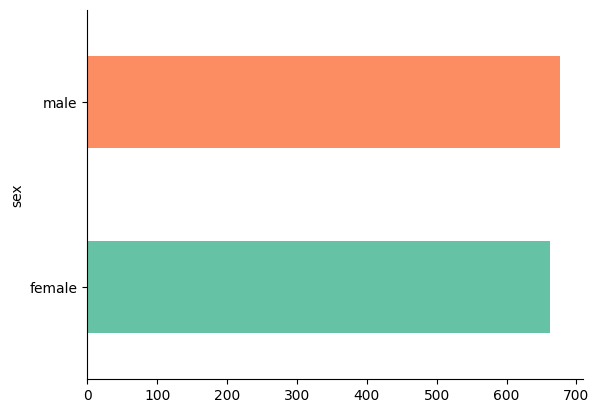

In [5]:
# existe el mismo número de registros por sexo?

import matplotlib.pyplot as plt
import seaborn as sns

data.groupby('sex').size().plot(kind='barh', color=sns.palettes.mpl_palette('Set2'))

plt.gca().spines[['top', 'right',]].set_visible(False)

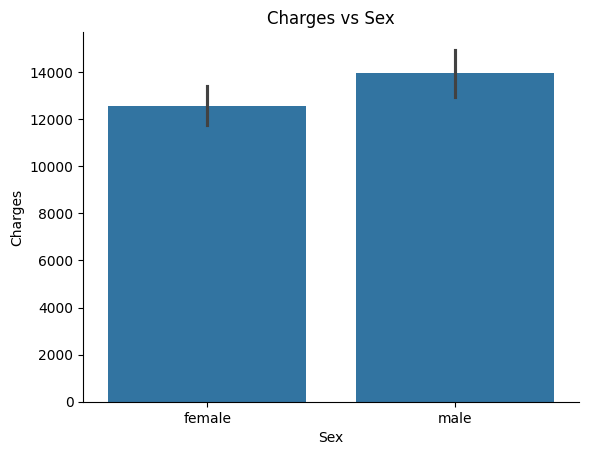

In [ ]:
# existe alguna diferencia en los costes de la poliza según el sexo?

import matplotlib.pyplot as plt
import seaborn as sns

# Create the bar plot
sns.barplot(x='sex', y='charges', data=data)

# Customize the plot
plt.xlabel('Sex')
plt.ylabel('Charges')
plt.title('Charges vs Sex')

plt.gca().spines[['top', 'right',]].set_visible(False)

# Show the plot
plt.show()


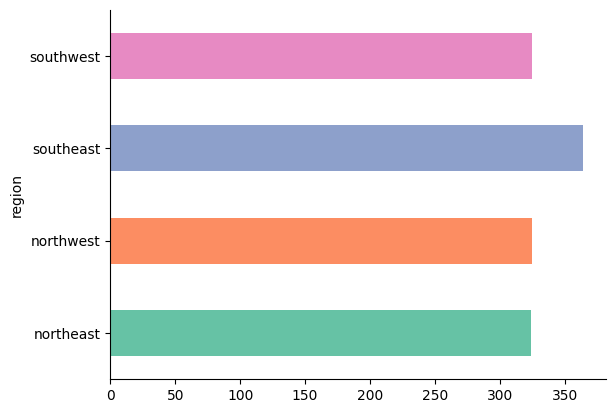

In [ ]:
# existe el mismo número de registros por región?

from matplotlib import pyplot as plt
import seaborn as sns

data.groupby('region').size().plot(kind='barh', color=sns.palettes.mpl_palette('Set2'))

plt.gca().spines[['top', 'right',]].set_visible(False)

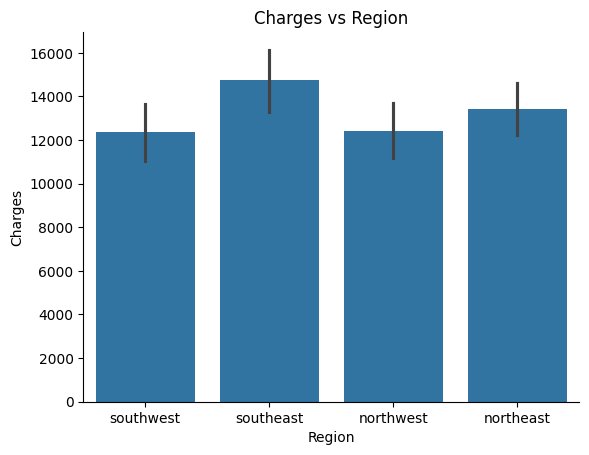

In [ ]:
# existe alguna diferencia de costes de las polizas según la región?

import matplotlib.pyplot as plt
# Create the bar plot
sns.barplot(x='region', y='charges', data=data)

# Customize the plot
plt.xlabel('Region')
plt.ylabel('Charges')
plt.title('Charges vs Region')

plt.gca().spines[['top', 'right',]].set_visible(False)

# Show the plot
plt.show()


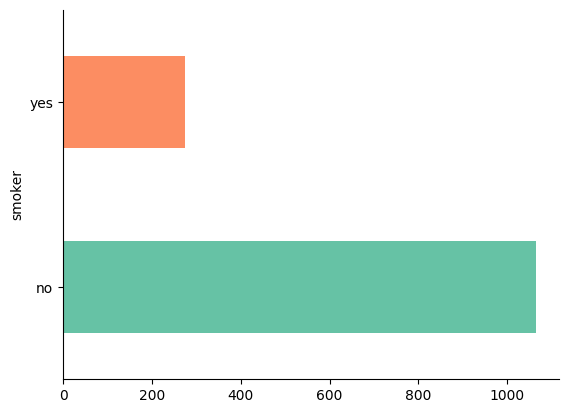

In [ ]:
# cuantos registros son de fumadores y cuantos de no fumadores?

import matplotlib.pyplot as plt
import seaborn as sns

data.groupby('smoker').size().plot(kind='barh', color=sns.palettes.mpl_palette('Set2'))

plt.gca().spines[['top', 'right',]].set_visible(False)


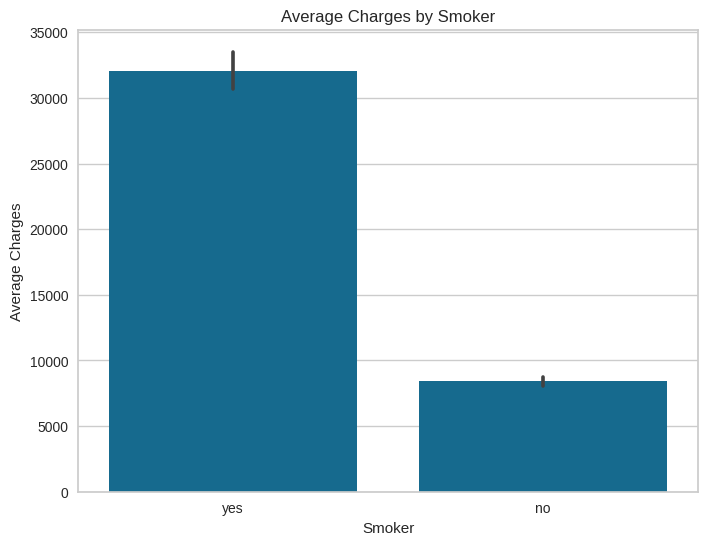

In [ ]:
# existe alguna diferencia de costes para los fumadores?

import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 6))
sns.barplot(x='smoker', y='charges', data=data)
plt.xlabel('Smoker')
plt.ylabel('Average Charges')
plt.title('Average Charges by Smoker')
plt.show()


Efectivamente existe una diferencia en el coste de la poliza. Los fumadores ven penalizada su poliza

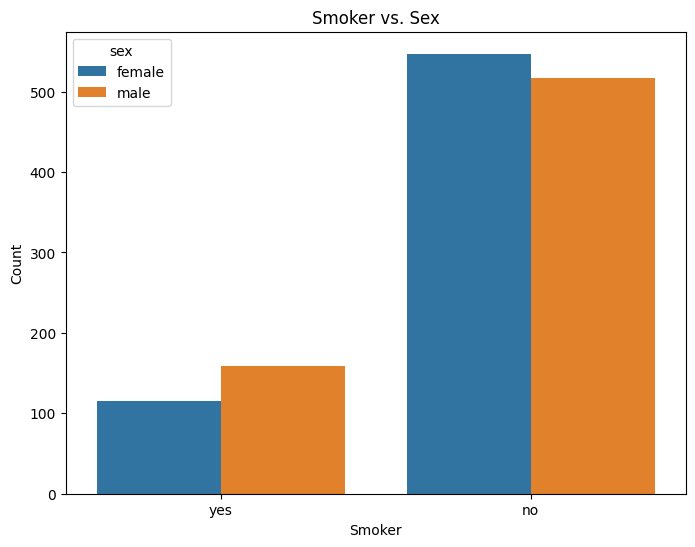

In [ ]:
# existe alguna diferencia de registros?

import matplotlib.pyplot as plt
# Assuming 'data' DataFrame from previous code is available

plt.figure(figsize=(8, 6))
sns.countplot(x='smoker', hue='sex', data=data)
plt.xlabel('Smoker')
plt.ylabel('Count')
plt.title('Smoker vs. Sex')
plt.show()


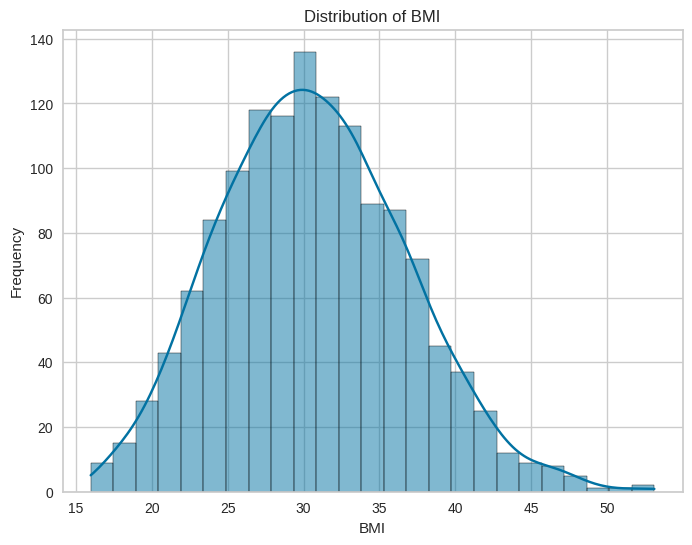

In [ ]:


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.histplot(data=data, x='bmi', kde=False)
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()


In [ ]:
# mostramos la relación fumadores vs no fumadores y el bmi

import plotly.express as px
fig = px.scatter(x=data['bmi'], y=data['charges'], facet_col = data['smoker'], opacity = 0.25, trendline='ols', trendline_color_override = 'red')
fig.show()

Ser fumador y tener un bmi alto penaliza enormemente la poliza!

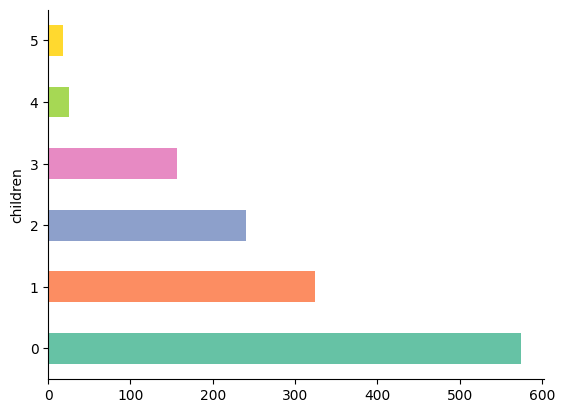

In [ ]:
# como se distribuye la variable "children"

import matplotlib.pyplot as plt
import seaborn as sns


# Group by 'children' and plot a horizontal bar chart
data.groupby('children').size().plot(kind='barh', color=sns.color_palette('Set2'))

# Remove top and right spines for aesthetics
plt.gca().spines[['top', 'right']].set_visible(False)

# Display the plot
plt.show()


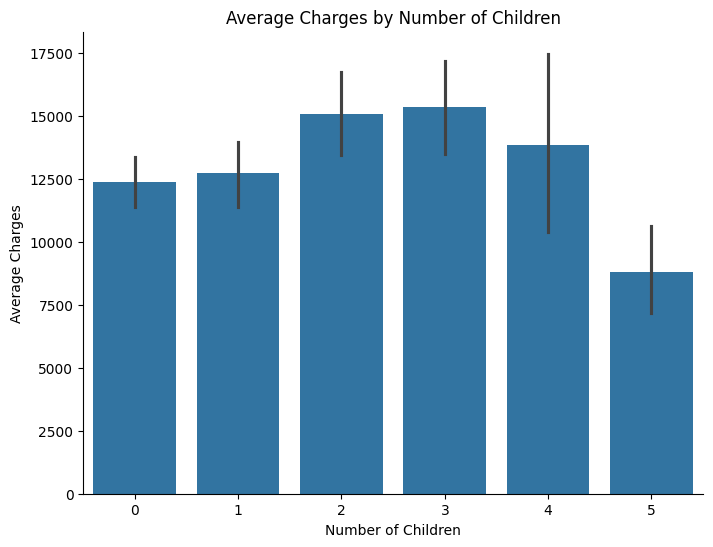

In [ ]:
# alguna diferencia en la poliza?

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'data' DataFrame is available (from previous code)

plt.figure(figsize=(8, 6))
sns.barplot(x='children', y='charges', data=data)
plt.xlabel('Number of Children')
plt.ylabel('Average Charges')
plt.title('Average Charges by Number of Children')
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.show()


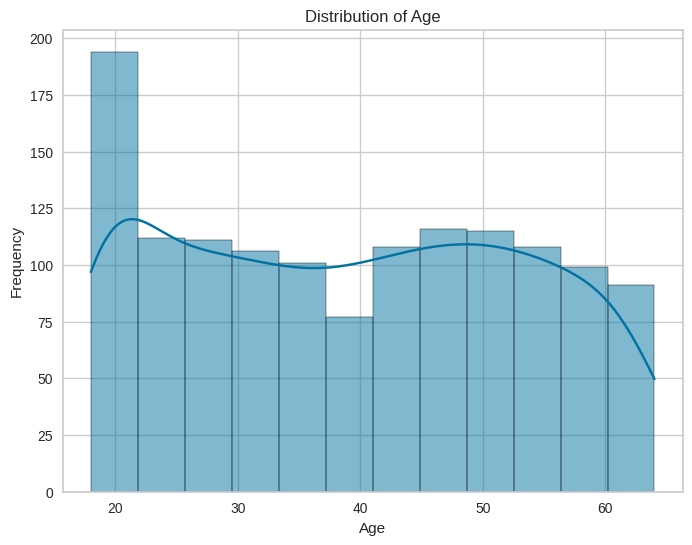

In [ ]:
# ¡

import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 6))
sns.histplot(data=data, x='age', kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


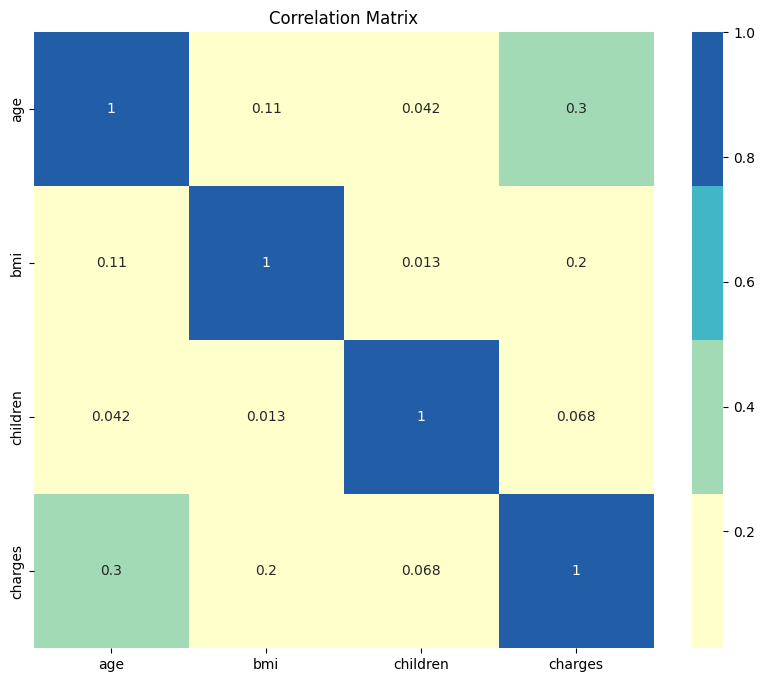

In [ ]:
# existe alguna correlación entre las variables numéricas?

import seaborn as sns
import matplotlib.pyplot as plt


# Create a custom colormap with modified color intensity
custom_cmap = sns.color_palette(['#ffffcc', '#a1dab4', '#41b6c4', '#225ea8'])
correlation_matrix = data[['age', 'bmi', 'children', 'charges']].corr()

# Create a heatmap with the custom colormap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap=custom_cmap)
plt.title('Correlation Matrix')
plt.show()

La matriz de correlación indica que existe alguna relación entre la edad y el indice de masa corporal.

Usamos Chi-Square para estudiar la relación entre las variables categóricas

In [ ]:
# crear grafico